In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import visualkeras
from PIL import ImageFont
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries

from tensorflow.keras.preprocessing import image_dataset_from_directory
import random
random.seed(42)

ds_name = "images"
ds_training_path = os.path.join(ds_name, "train")
ds_testing_path = os.path.join(ds_name, "test")

batch_size = 16
target_size = (224, 224)
random_seed = 55
num_classes = 5
epochs = 128

data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = data_gen.flow_from_directory(
    ds_training_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True,
    seed=random_seed
)

valid_gen = data_gen.flow_from_directory(
    ds_testing_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

In [ ]:
def text_callable(layer_index, layer):
    # Every other piece of text is drawn above the layer, the first one below
    above = bool(layer_index%2)

    # Get the output shape of the layer
    output_shape = [x for x in list(layer.output_shape) if x is not None]

    # If the output shape is a list of tuples, we only take the first one
    if isinstance(output_shape[0], tuple):
        output_shape = list(output_shape[0])
        output_shape = [x for x in output_shape if x is not None]

    # Variable to store text which will be drawn    
    output_shape_txt = ""

    # Create a string representation of the output shape
    for ii in range(len(output_shape)):
        output_shape_txt += str(output_shape[ii])
        if ii < len(output_shape) - 2: # Add an x between dimensions, e.g. 3x3
            output_shape_txt += "x"
        if ii == len(output_shape) - 2: # Add a newline between the last two dimensions, e.g. 3x3 \n 64
            output_shape_txt += "\n"

    # Add the name of the layer to the text, as a new line
    output_shape_txt += f"\n{layer.name}"

    # Return the text value and if it should be drawn above the layer
    return output_shape_txt, above

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Reshape, multiply, Activation
from tensorflow.keras import backend as K  # Keras backend modülünü import etme

# Squeeze-and-Excitation bloğu
def squeeze_excite_block(input, ratio=16):
    init = input
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    filters = init.shape[channel_axis]
    se_shape = (1, 1, filters)

    se = GlobalAveragePooling2D()(init)
    se = Reshape(se_shape)(se)
    se = Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)

    x = multiply([init, se])
    return x

# Modeli oluşturma
input_layer = Input(shape=(224, 224, 3))

# 1. Evrişim Katmanı
x = Conv2D(32, (3, 3), activation='relu')(input_layer)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)

# 2. Evrişim Katmanı
x = Conv2D(64, (3, 3), activation='relu')(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)

# 3. Evrişim Katmanı
x = Conv2D(128, (3, 3), activation='relu')(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)

# 4. Evrişim Katmanı
x = Conv2D(256, (3, 3), activation='relu')(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)

# 5. Evrişim Katmanı
x = Conv2D(512, (3, 3), activation='relu')(x)
x = squeeze_excite_block(x)
x = MaxPooling2D((2, 2))(x)

# Düzleştirme katmanı
x = Flatten()(x)

# Tam bağlantılı katmanlar
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Çıkış katmanı (örneğin, 10 sınıflı bir sınıflandırma için)
output_layer = Dense(num_classes, activation='softmax')(x)

# Modeli oluşturma
model = Model(inputs=input_layer, outputs=output_layer)

# Modeli derleme
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Modelin özetini yazdırma
model.summary()


In [ ]:
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)  # using comic sans is strictly prohibited!
visualkeras.layered_view(model, 
                            draw_volume=True,
                            legend=False, 
                            font=font, 
                            show_dimension=True,
                            scale_xy=3, 
                            scale_z=.1,
                            max_z=80,
                            spacing=25, 
                            text_callable=text_callable  # Özelleştirilmiş metin fonksiyonunu ekler
                         )

In [ ]:
from PIL import ImageFont
font = ImageFont.truetype("arial.ttf", 12)  # using comic sans is strictly prohibited!
visualkeras.layered_view(model, 
                            draw_volume=False,
                            legend=False, 
                            font=font, 
                            show_dimension=False,
                            scale_xy=1, 
                            scale_z=.1,
                            max_z=80,
                            spacing=30, 
                           #  text_callable=text_callable  # Özelleştirilmiş metin fonksiyonunu ekler
                         )

In [28]:
# Modeli eğitmek için kod
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Metric to monitor for improvement
    patience=3,  # Number of epochs to wait before stopping
    restore_best_weights=True  # Restore the best model weights
)

# Train the model
callbacks=[early_stopping]

history= model.fit(
    train_gen,
    epochs=epochs,
    batch_size=batch_size, # Number
    validation_data=valid_gen,
    callbacks=callbacks
)

203/203 [==============================] - 22s 95ms/step - loss: 1.5134 - accuracy: 0.2797 - val_loss: 1.3048 - val_accuracy: 0.3605
Epoch 2/128
203/203 [==============================] - 19s 92ms/step - loss: 1.2954 - accuracy: 0.4202 - val_loss: 1.2932 - val_accuracy: 0.3889
Epoch 3/128
203/203 [==============================] - 18s 90ms/step - loss: 1.1480 - accuracy: 0.5218 - val_loss: 0.9643 - val_accuracy: 0.6074
Epoch 4/128
203/203 [==============================] - 19s 95ms/step - loss: 1.0630 - accuracy: 0.5885 - val_loss: 0.9397 - val_accuracy: 0.6210
Epoch 5/128
203/203 [==============================] - 19s 93ms/step - loss: 0.9818 - accuracy: 0.6169 - val_loss: 0.8861 - val_accuracy: 0.6630
Epoch 6/128
203/203 [==============================] - 17s 85ms/step - loss: 0.9239 - accuracy: 0.6650 - val_loss: 0.8871 - val_accuracy: 0.6716
Epoch 7/128
203/203 [==============================] - 18s 87ms/step - loss: 0.8588 - accuracy: 0.7005 - val_loss: 0.8662 - val_accuracy: 0.72

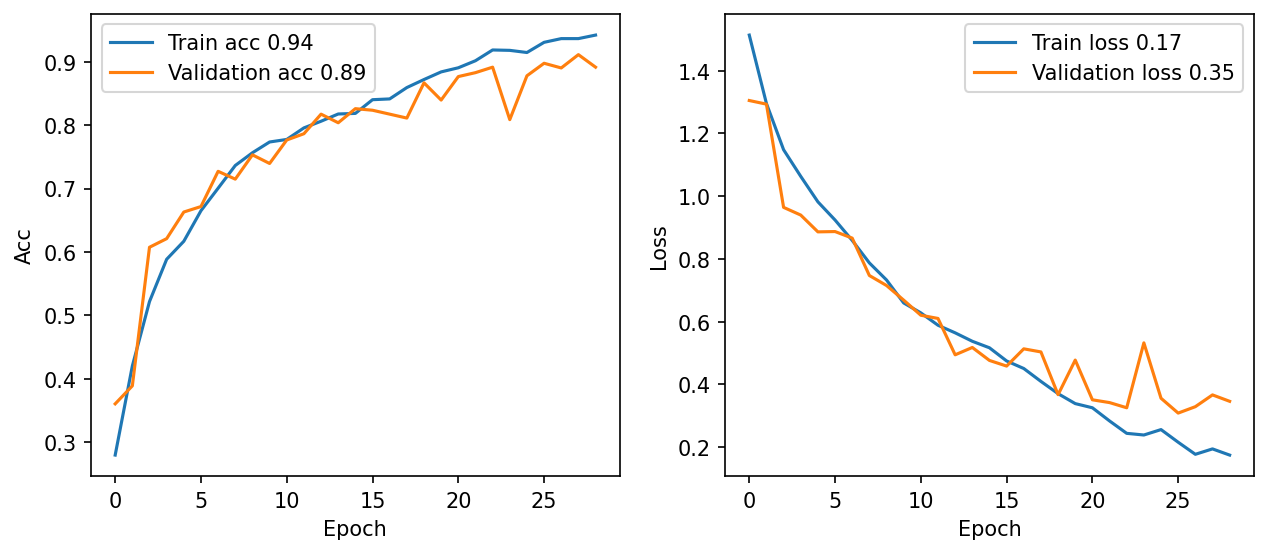

In [29]:
from helper import Helper
_helper = Helper()
_helper.plot_train_and_val_curves(history)

51/51 [==============================] - 4s 64ms/step


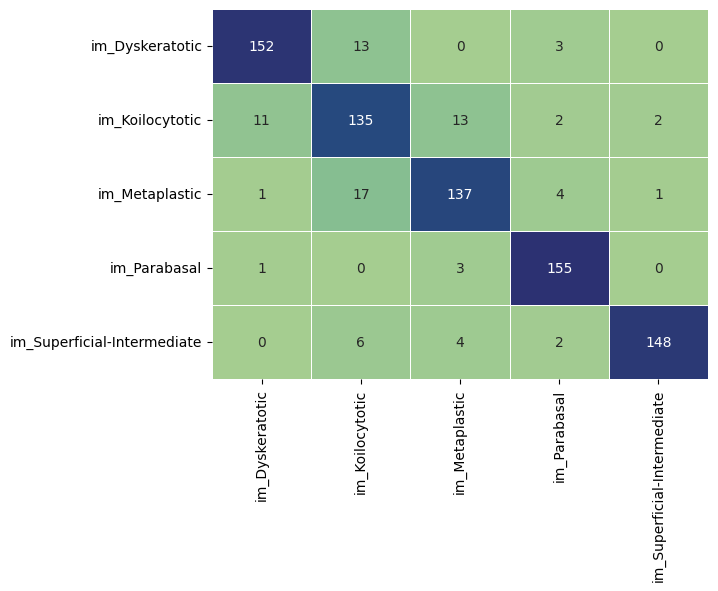

In [30]:
_helper.plot_confusion_matrix(model, valid_gen)

51/51 [==============================] - 4s 69ms/step


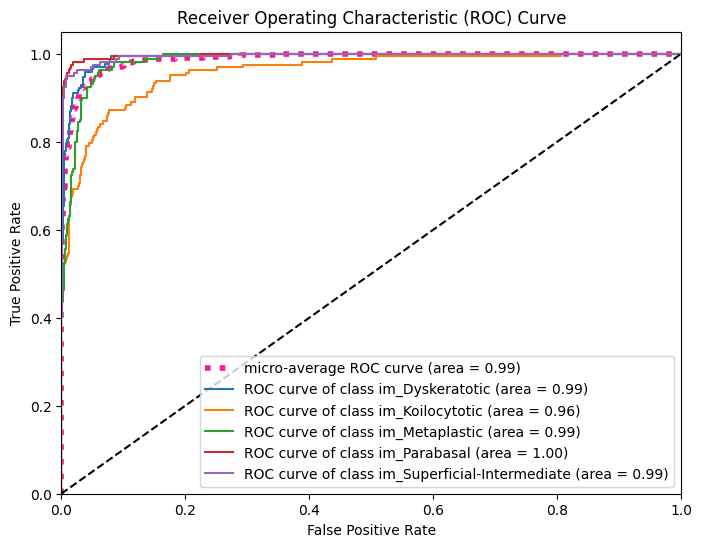

In [31]:
_helper.plot_roc_curve(model, valid_gen)

In [32]:
import pickle
model.save("model2.h5")
# history değişkenini pickle ile kaydetme
with open('model2.pkl', 'wb') as file:
    pickle.dump(history.history, file)

In [33]:
from confusion import Confusion
cm = _helper.get_confusion_matrix(model, valid_gen)
Confusion.getValues(cm)

51/51 [==============================] - 3s 64ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       168
           1       0.79      0.83      0.81       163
           2       0.87      0.86      0.86       160
           3       0.93      0.97      0.95       159
           4       0.98      0.93      0.95       160

    accuracy                           0.90       810
   macro avg       0.90      0.90      0.90       810
weighted avg       0.90      0.90      0.90       810

Confusion Matrix:
[[152  13   0   3   0]
 [ 11 135  13   2   2]
 [  1  17 137   4   1]
 [  1   0   3 155   0]
 [  0   6   4   2 148]]


,Value
Accuracy,0.8975
Error,0.1025
Sensitivity,0.8978
Specificity,0.9744
Precision,0.8994
FalsePositiveRate,0.0256
F1_score,0.8983
MatthewsCorrelationCoefficient,0.8729
